# Practice Lab: 线性回归

欢迎来到你的第一个实践实验室！在这个实验室中，你将使用单变量线性回归来预测餐厅连锁店的利润。
# 大纲
- [1 - 包](#1)
- [2 - 单变量线性回归](#2)
  - [2.1 问题陈述](#2.1)
  - [2.2 数据集](#2.2)
  - [2.3 线性回归复习](#2.3)
  - [2.4 计算成本](#2.4)
    - [练习 1](#ex01)
  - [2.5 梯度下降](#2.5)
    - [练习 2](#ex02)
  - [2.6 使用批量梯度下降学习参数](#2.6)


<a name="1"></a>
## 1 - 包
首先，让我们运行下面的单元格以导入在本次作业中你将需要的所有包。
- [numpy](www.numpy.org)是在 Python 中处理矩阵的基础包。
- [matplotlib](http://matplotlib.org)是一个在 Python 中绘制图形的著名库。
- “utils.py”包含本次作业的辅助函数。你不需要修改这个文件中的代码。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import copy
import math
%matplotlib widget

## 2 - 问题陈述
假设你是一家连锁餐厅的首席执行官，正在考虑在不同的城市开设一家新的门店。
- 你希望将业务扩展到可能给你的餐厅带来更高利润的城市。
- 该连锁餐厅已经在各个城市拥有门店，并且你拥有来自这些城市的利润和人口数据。
- 你也有作为新餐厅候选城市的数据。
    - 对于这些城市，你拥有城市人口数据。
你能否使用这些数据来帮助你确定哪些城市可能会给你的业务带来更高的利润？
## 3 - 数据集
你将从加载此任务的数据集开始。
- 下面显示的`load_data()`函数将数据加载到变量`x_train`和`y_train`中。
  - `x_train`是一个城市的人口。
  - `y_train`是该城市中一家餐厅的利润。利润为负值表示亏损。
  - `x_train`和`y_train`都是 numpy 数组。

In [2]:
# load the dataset
x_train, y_train = load_data()

#### 查看变量
在开始任何任务之前，熟悉你的数据集是很有用的。
- 一个好的起点是打印出每个变量，看看它包含什么内容。

下面的代码打印变量`x_train`以及该变量的类型。

In [3]:
# print x_train
print("Type of x_train:",type(x_train))
print("First five elements of x_train are:\n", x_train[:5]) 

Type of x_train: <class 'numpy.ndarray'>
First five elements of x_train are:
 [6.1101 5.5277 8.5186 7.0032 5.8598]


`x_train`是一个 numpy 数组，其中包含的十进制值都大于零。
- 这些值表示城市人口乘以 10000。
- 例如，6.1101 意味着该城市的人口是 61101。

现在，让我们打印`y_train`。

In [4]:
# print y_train
print("Type of y_train:",type(y_train))
print("First five elements of y_train are:\n", y_train[:5])  

Type of y_train: <class 'numpy.ndarray'>
First five elements of y_train are:
 [17.592   9.1302 13.662  11.854   6.8233]


同样，`y_train`是一个 numpy 数组，包含一些十进制值，有正有负。
- 这些值代表你餐厅在每个城市的平均月利润，单位为 10000 美元。
  - 例如，17.592 代表该城市平均月利润为 175920 美元。
  - -2.6807 代表该城市平均月亏损为 26807 美元。

#### 检查变量的维度
了解数据的另一个有用方法是查看其维度。
请打印`x_train`和`y_train`的形状，并查看数据集中有多少个训练样本。

In [5]:
print ('The shape of x_train is:', x_train.shape)
print ('The shape of y_train is: ', y_train.shape)
print ('Number of training examples (m):', len(x_train))

The shape of x_train is: (97,)
The shape of y_train is:  (97,)
Number of training examples (m): 97


城市人口数组有 97 个数据点，月平均利润也有 97 个数据点。这些是 NumPy 的一维数组。

#### 可视化你的数据
通过可视化数据来理解数据通常是很有用的。
- 对于这个数据集，你可以使用散点图来可视化数据，因为它只有两个要绘制的属性（利润和人口）。
- 你在现实生活中会遇到的许多其他问题有两个以上的属性（例如，人口、平均家庭收入、月利润、月销售额）。当你有两个以上的属性时，你仍然可以使用散点图来查看每对属性之间的关系。


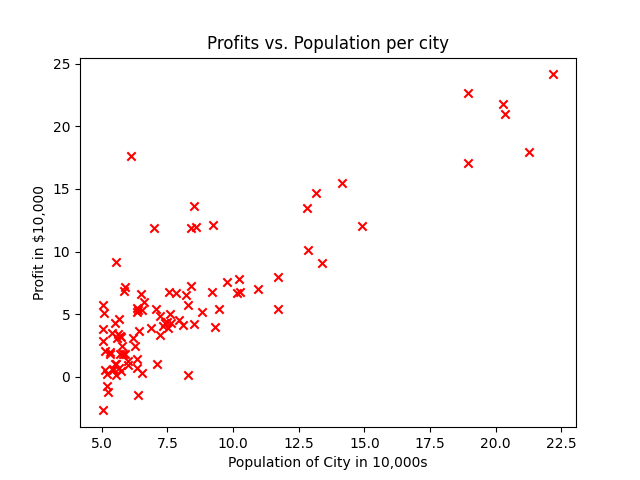

In [6]:
# Create a scatter plot of the data. To change the markers to red "x",
# we used the 'marker' and 'c' parameters
plt.scatter(x_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')
plt.show()

你的目标是建立一个线性回归模型来拟合这些数据。
- 有了这个模型，你就可以输入一个新城市的人口，然后让模型估计你的餐厅在那个城市的潜在月利润。

<a name="4"></a>
## 4 - 线性回归复习
在这个实践实验室中，你将把线性回归参数(w,b)拟合到你的数据集。
- 线性回归的模型函数是一个将`x`（城市人口）映射到`y`（你的餐厅在该城市的每月利润）的函数，表示为
    $$f_{w,b}(x) = wx + b$$
- 为了训练一个线性回归模型，你想要找到最适合你的数据集的最佳(w,b)参数。
    - 为了比较一个(w,b)的选择比另一个选择更好或更差，你可以用成本函数$J(w,b)$来评估它。
      - $J$是(w,b)的函数。也就是说，成本$J(w,b)$的值取决于(w,b)的值。
    - 最适合你的数据的(w,b)的选择是具有最小成本$J(w,b)$的那个。
- 为了找到获得最小可能成本$J(w,b)$的(w,b)的值，你可以使用一种叫做**梯度下降**的方法。
  - 随着梯度下降的每一步，你的参数(w,b)会越来越接近将实现最低成本$J(w,b)$的最佳值。
- 训练后的线性回归模型可以接受输入特征$x$（城市人口）并输出预测值$f_{w,b}(x)$（该城市餐厅的预计每月利润）。


<a name="5"></a>
## 5 - 计算成本
梯度下降涉及重复步骤来调整参数$(w,b)$的值，以逐渐获得越来越小的成本$J(w,b)$。
- 在梯度下降的每一步中，随着$(w,b)$的更新计算成本$J(w,b)$，这将有助于你监控进度。
- 在本节中，你将实现一个函数来计算$J(w,b)$，以便可以检查梯度下降实现的进度。
#### 成本函数
正如你可能从讲座中回忆起的那样，对于单变量，线性回归的成本函数$J(w,b)$定义为
$$J(w,b)=\frac{1}{2m}\sum\limits_{i = 0}^{m - 1}(f_{w,b}(x^{(i)}) - y^{(i)})^2$$
- 你可以将$f_{w,b}(x^{(i)})$视为模型对你餐厅利润的预测，而$y^{(i)}$是数据中记录的实际利润。
- $m$是数据集中的训练样本数量。
#### 模型预测
- 对于单变量线性回归，模型$f_{w,b}$对示例$x^{(i)}$的预测表示为：
$$f_{w,b}(x^{(i)}) = wx^{(i)} + b$$
这是一条直线的方程，具有截距$b$和斜率$w$。
#### 实现
请完成下面的`compute_cost()`函数以计算成本$J(w,b)$。

<a name="ex01"></a>
### 练习 1
完成下面的`compute_cost`以实现：
* 遍历训练样本，对于每个样本，计算：
    * 模型对该样本的预测
    $$
    f_{wb}(x^{(i)}) =  wx^{(i)} + b 
    $$
    * 该样本的成本
    $$cost^{(i)} =  (f_{wb} - y^{(i)})^2$$
* 返回所有样本的总成本
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} cost^{(i)}$$
  * 这里，$m$是训练样本的数量，$\sum$是求和运算符。
如果你遇到困难，可以查看下面单元格后的提示来帮助你实现。

In [7]:
# UNQ_C1
# GRADED FUNCTION: compute_cost

def compute_cost(x, y, w, b): 
    """
    Computes the cost function for linear regression.
    
    Args:
        x (ndarray): Shape (m,) Input to the model (Population of cities) 
        y (ndarray): Shape (m,) Label (Actual profits for the cities)
        w, b (scalar): Parameters of the model
    
    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    # 训练样本个数
    m = x.shape[0] 

    # 你需要正确地返回这个变量。
    total_cost = 0

    ### START CODE HERE ###  
    # 用于跟踪每个示例的成本总和的变量
    cost_sum = 0

    # 遍历训练样本
    for i in range(m):
        # 在这里输入你的代码以获取第 i 个示例的预测值 f_wb。
        f_wb =  w * x[i] + b
        # 在这里输入你的代码以获取与第 i 个示例相关的成本。
        cost = (f_wb - y[i]) ** 2
    
        # 将其加到每个示例的成本总和中。
        cost_sum = cost_sum + cost 

    # 获取总成本，将总和除以(2 * m)。
    total_cost = (1 / (2 * m)) * cost_sum
    ### END CODE HERE ### 

    return total_cost

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
    
    
   * 你可以像下面这样在代码中表示一个求和运算符 $h = \sum\limits_{i = 0}^{m-1} 2i$ :

```python 
    h = 0
    for i in range(m):
        h = h + 2*i
```
  
   * 在这种情况下，你可以使用一个 for 循环遍历`x`中的所有示例，并将每次迭代中的`cost`添加到在循环外部初始化的变量（`cost_sum`）中。

   * 然后，你可以将`total_cost`作为`cost_sum`除以`2m`返回。
     
<details>
    <summary><font size="2" color="darkblue"><b> 点击获取更多提示 </b></font></summary>
        
   * 以下是你可以为这个函数构建整体实现的方法。
    
```python 
def compute_cost(x, y, w, b):
    # 训练样本个数
    m = x.shape[0] 

    # 你需要正确地返回这个变量。
    total_cost = 0

    ### START CODE HERE ###  
    # 用于跟踪每个示例的成本总和的变量
    cost_sum = 0

    # 遍历训练样本
    for i in range(m):
        # 在这里输入你的代码以获取第 i 个示例的预测值 f_wb。
        f_wb =  w * x[i] + b
        # 在这里输入你的代码以获取与第 i 个示例相关的成本。
        cost = (f_wb - y[i]) ** 2
    
        # 将其加到每个示例的成本总和中。
        cost_sum = cost_sum + cost 

    # 获取总成本，将总和除以(2 * m)。
    total_cost = (1 / (2 * m)) * cost_sum
    ### END CODE HERE ### 

    return total_cost
```
    
* 如果你仍然陷入困境，可以查看下面给出的提示，以弄清楚如何计算`f_wb`和`cost`。
    
<details>
          <summary><font size="2" color="darkblue"><b>提示：计算f_wb</b></font></summary>
           &emsp;&emsp;对于标量 $a$、$b$ 和 $c$（<code>x[i]</code>、<code>w</code> 和 <code>b</code> 都是标量），你可以在代码中像这样计算方程 $h = ab + c$：<code>h = a * b + c</code>。
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 更多提示：计算f_wb</b></font></summary>
               &emsp;&emsp;你可以像这样计算 f_wb：<code>f_wb = w * x[i] + b </code>
           </details>
</details>

<details>
          <summary><font size="2" color="darkblue"><b>提示：计算cost</b></font></summary>
          &emsp;&emsp;你可以将变量 z 的平方计算为 z**2。
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 更多提示：计算cost</b></font></summary>
              &emsp;&emsp;你可以像这样计算成本：<code>cost = (f_wb - y[i]) ** 2</code>
          </details>
    </details>
        
</details>

</details>

    


你可以通过运行以下测试代码来检查你的实现是否正确：

In [8]:
# Compute cost with some initial values for paramaters w, b
initial_w = 2
initial_b = 1

cost = compute_cost(x_train, y_train, initial_w, initial_b)
print(type(cost))
print(f'Cost at initial w (zeros): {cost:.3f}')

# Public tests
from public_tests import *
compute_cost_test(compute_cost)

<class 'numpy.float64'>
Cost at initial w (zeros): 75.203
All tests passed!


**Expected Output**:
<table>
  <tr>
    <td> <b>Cost at initial w (zeros):<b> 75.203 </td> 
  </tr>
</table>

<a name="6"></a>
## 6 - 梯度下降
在本节中，你将为线性回归实现参数$w$、$b$的梯度。
正如在讲座视频中所描述的，梯度下降算法是：

正如在讲座视频中所描述的，梯度下降算法是：

$$\begin{align*}& \text{重复直到收敛:} \; \lbrace \newline \; & \phantom {0000} b := b -  \alpha \frac{\partial J(w,b)}{\partial b} \newline       \; & \phantom {0000} w := w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{1}  \; & 
\newline & \rbrace\end{align*}$$

其中，参数$w$、$b$同时更新，并且
$$
\frac{\partial J(w,b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{2}
$$
$$
\frac{\partial J(w,b)}{\partial w}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) -y^{(i)})x^{(i)} \tag{3}
$$
* m 是数据集中训练样本的数量。

    
*  $f_{w,b}(x^{(i)})$是模型的预测值，而$y^{(i)}$是目标值。


你将实现一个名为`compute_gradient`的函数，该函数用于计算
$\frac{\partial J(w)}{\partial w}$, $\frac{\partial J(w)}{\partial b}$ 

<a name="ex02"></a>
### 练习 2
请完成`compute_gradient`函数以：
- 遍历训练样本，对于每个样本，计算：
    - 该样本的模型预测值：$$f_{wb}(x^{(i)}) = wx^{(i)} + b$$
    - 该样本对参数$w$、$b$的梯度：
  $$
  \frac{\partial J(w,b)}{\partial b}^{(i)}=(f_{w,b}(x^{(i)}) - y^{(i)})
  $$
  
  $$
  \frac{\partial J(w,b)}{\partial w}^{(i)}=(f_{w,b}(x^{(i)}) -y^{(i)})x^{(i)}
  $$

- 返回所有样本的总梯度更新。
    $$
    \frac{\partial J(w,b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(w,b)}{\partial b}^{(i)}
    $$
    
    $$
    \frac{\partial J(w,b)}{\partial w}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(w,b)}{\partial w}^{(i)} 
    $$

- 在这里，$m$是训练样本的数量，$\sum$是求和运算符。


如果遇到困难，你可以查看下面单元格之后给出的提示来帮助你实现。

In [9]:
# UNQ_C2
# GRADED FUNCTION: compute_gradient
def compute_gradient(x, y, w, b): 
    """
    Computes the gradient for linear regression 
    Args:
      x (ndarray): Shape (m,) Input to the model (Population of cities) 
      y (ndarray): Shape (m,) Label (Actual profits for the cities)
      w, b (scalar): Parameters of the model  
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
     """
    
    # Number of training examples
    m = x.shape[0]
    
    # You need to return the following variables correctly
    dj_dw = 0
    dj_db = 0
    
    ### START CODE HERE ### 
    # Loop over examples
    for i in range(m):  
        # Your code here to get prediction f_wb for the ith example
        f_wb =  w * x[i] + b 
        
        # Your code here to get the gradient for w from the ith example 
        dj_dw_i = (f_wb - y[i]) * x[i]
    
        # Your code here to get the gradient for b from the ith example 
        dj_db_i = f_wb - y[i] 
 
        # Update dj_db : In Python, a += 1  is the same as a = a + 1
        dj_db += dj_db_i
    
        # Update dj_dw
        dj_dw += dj_dw_i

    # Divide both dj_dw and dj_db by m
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    ### END CODE HERE ### 
        
    return dj_dw, dj_db

<details>
  <summary><font size="3" color="darkgreen"><b>点击获取提示</b></font></summary>
       
* 你可以用如下方式在代码中表示一个求和运算符$h = \sum\limits_{i = 0}^{m-1} 2i$，  例如:
    
```python 
    h = 0
    for i in range(m):
        h = h + 2*i
```
    
* 在这种情况下，你可以使用一个for循环遍历`x`中的所有示例，对于每个示例，不断将该示例的梯度添加到在循环外部初始化的变量`dj_dw`和`dj_db`中。 

* 然后，你可以返回`dj_dw`和`dj_db`两者都除以`m`的值。

<details>
    <summary><font size="2" color="darkblue"><b> Click for more hints</b></font></summary>
        
* 以下是你可以如何构建此函数的整体实现方式。

```python 
    def compute_gradient(x, y, w, b): 
        """
        Computes the gradient for linear regression 
        Args:
          x (ndarray): Shape (m,) Input to the model (Population of cities) 
          y (ndarray): Shape (m,) Label (Actual profits for the cities)
          w, b (scalar): Parameters of the model  
        Returns
          dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
          dj_db (scalar): The gradient of the cost w.r.t. the parameter b     
         """
    
        # Number of training examples
        m = x.shape[0]
    
        # You need to return the following variables correctly
        dj_dw = 0
        dj_db = 0
    
        ### START CODE HERE ### 
        # Loop over examples
        for i in range(m):  
            # Your code here to get prediction f_wb for the ith example
            f_wb = 
            
            # Your code here to get the gradient for w from the ith example 
            dj_dw_i = 
        
            # Your code here to get the gradient for b from the ith example 
            dj_db_i = 
     
            # Update dj_db : In Python, a += 1  is the same as a = a + 1
            dj_db += dj_db_i
        
            # Update dj_dw
            dj_dw += dj_dw_i
    
        # Divide both dj_dw and dj_db by m
        dj_dw = dj_dw / m
        dj_db = dj_db / m
        ### END CODE HERE ### 
        
        return dj_dw, dj_db
```
    
* 如果您仍然陷入困境，可以查看下面提供的提示，以了解如何计算`f_wb`和`cost`。
    
<details>
    <summary><font size="2" color="darkblue"><b>计算f_wb的提示</b></font></summary>
           &emsp; &emsp; 你在前面的练习中做过这个！对于标量$a$、$b$和$c$。(<code>x[i]</code>, <code>w</code> and <code>b</code> are all scalars), you can calculate the equation $h = ab + c$ in code as <code>h = a * b + c</code>
    <details>
      <summary><font size="2" color="blue"><b>&emsp; &emsp; 更多计算f_wb的提示</b></font></summary>
       &emsp; &emsp; 你可以将 f_wb 计算为 <code>f_wb = w * x[i] + b </code>
   </details>
</details>
        
<details>
      <summary><font size="2" color="darkblue"><b>计算 dj_dw_i 的提示</b></font></summary>
       &emsp; &emsp;对于标量$a$、$b$和$c$（<code>f_wb</code>、<code>y[i]</code>和<code>x[i]</code>均为标量），在代码中可以将方程$h = (a - b)c$计算为<code>h = (a - b)*c</code>。
      <details>
          <summary><font size="2" color="blue"><b>&emsp; &emsp; 更多计算 dj_dw_i 的提示</b></font></summary>
           &emsp; &emsp; 你可以将 $dj\_dw\_i$ 计算为 <code>dj_dw_i = (f_wb - y[i]) * x[i] </code>
       </details>
</details>
        
<details>
      <summary><font size="2" color="darkblue"><b>计算 dj_db_i 的提示</b></font></summary>
         &emsp; &emsp; 你可以将 dj_db_i 计算为 <code>dj_db_i = f_wb - y[i]</code>。
</details>
        
</details>

</details>

    


运行下面的单元格，以检查你对参数$w$、$b$的两种不同初始化情况下的`compute_gradient`函数的实现。

In [10]:
# Compute and display gradient with w initialized to zeroes
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

compute_gradient_test(compute_gradient)

Gradient at initial w, b (zeros): -65.32884974555672 -5.83913505154639
Using X with shape (4, 1)
All tests passed!


现在，让我们在我们的数据集上运行上面实现的梯度下降算法。
**Expected Output**:
<table>
  <tr>
    <td> <b>初始状态下的梯度，b（初始值为零）<b></td>
    <td> -65.32884975 -5.83913505154639</td> 
  </tr>
</table>

In [11]:
# Compute and display cost and gradient with non-zero w
test_w = 0.2
test_b = 0.2
tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, test_w, test_b)

print('Gradient at test w, b:', tmp_dj_dw, tmp_dj_db)

Gradient at test w, b: -47.41610118114435 -4.007175051546391


**预期输出**:
<table>
  <tr>
    <td> <b>测试 w 处的梯度<b></td>
    <td> -47.41610118 -4.007175051546391</td> 
  </tr>
</table>

<a name="2.6"></a>
### 2.6 使用批量梯度下降学习参数
你现在将通过使用批量梯度下降来找到线性回归模型的最优参数。回想一下，批量是指在一次迭代中运行所有的示例。
- 对于这部分内容你不需要实现任何东西。只需运行下面的单元格。
- 验证梯度下降是否正确工作的一个好方法是查看$J(w,b)$的值，并检查它在每一步中是否在减小。
- 假设你已经正确地实现了梯度并计算了成本，并且你有一个合适的学习率 alpha 的值，那么$J(w,b)$应该永远不会增加，并且在算法结束时应该收敛到一个稳定的值。

In [12]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      x :    (ndarray): Shape (m,)
      y :    (ndarray): Shape (m,)
      w_in, b_in : (scalar) Initial values of parameters of the model
      cost_function: function to compute cost
      gradient_function: function to compute the gradient
      alpha : (float) Learning rate
      num_iters : (int) number of iterations to run gradient descent
    Returns
      w : (ndarray): Shape (1,) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(x)
    
    # An array to store cost J and w's at each iteration — primarily for graphing later
    J_history = []
    w_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_dw, dj_db = gradient_function(x, y, w, b )  

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(x, y, w, b)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0:
            w_history.append(w)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w, b, J_history, w_history #return w and J,w history for graphing

现在让我们运行上面的梯度下降算法，为我们的数据集学习参数。

In [13]:
# initialize fitting parameters. Recall that the shape of w is (n,)
initial_w = 0.
initial_b = 0.

# some gradient descent settings
iterations = 1500
alpha = 0.01

w,b,_,_ = gradient_descent(x_train ,y_train, initial_w, initial_b, 
                     compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

Iteration    0: Cost     6.74   
Iteration  150: Cost     5.31   
Iteration  300: Cost     4.96   
Iteration  450: Cost     4.76   
Iteration  600: Cost     4.64   
Iteration  750: Cost     4.57   
Iteration  900: Cost     4.53   
Iteration 1050: Cost     4.51   
Iteration 1200: Cost     4.50   
Iteration 1350: Cost     4.49   
w,b found by gradient descent: 1.166362350335582 -3.63029143940436


**预期输出**:
<table>
  <tr>
    <td> <b> w、b 通过梯度下降找到 <b></td>
    <td> 1.16636235 -3.63029143940436</td> 
  </tr>
</table>

我们现在将使用梯度下降得到的最终参数来绘制线性拟合。

回想一下，对于单个样本，我们可以得到预测值：$f(x^{(i)})=wx^{(i)}+b$。

为了计算整个数据集上的预测值，我们可以遍历所有的训练样本并为每个样本计算预测值。如下面的代码块所示。

In [14]:
m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * x_train[i] + b

我们现在将绘制预测值以查看线性拟合。

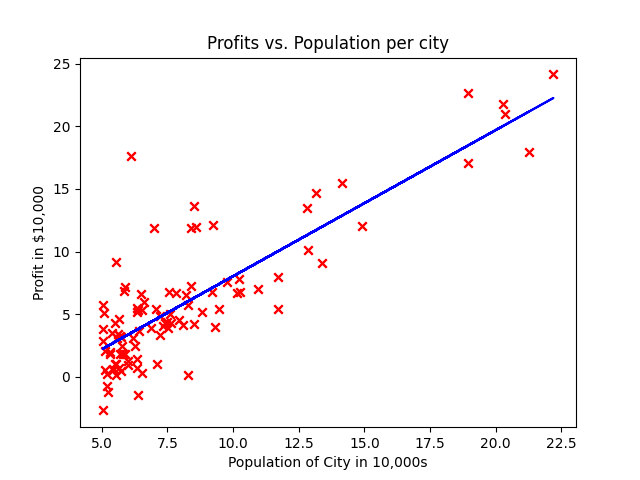

In [15]:
# Plot the linear fit
plt.plot(x_train, predicted, c = "b")

# Create a scatter plot of the data. 
plt.scatter(x_train, y_train, marker='x', c='r') 

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in $10,000')
# Set the x-axis label
plt.xlabel('Population of City in 10,000s')
plt.show()

你最终的$w$、$b$值也可用于对利润进行预测。让我们预测一下在人口为 35000 和 70000 的地区利润会是多少。
- 该模型将以城市人口（以万为单位）作为输入。
- 因此，35000 人可以转换为模型的输入`np.array([3.5])`。
- 类似地，70000 人可以转换为模型的输入`np.array([7.])`。


In [16]:
predict1 = 3.5 * w + b
print('For population = 35,000, we predict a profit of $%.2f' % (predict1*10000))

predict2 = 7.0 * w + b
print('For population = 70,000, we predict a profit of $%.2f' % (predict2*10000))

For population = 35,000, we predict a profit of $4519.77
For population = 70,000, we predict a profit of $45342.45


**预期输出**:
<table>
  <tr>
    <td> <b> 对于人口数量为 35000，我们预测利润为……<b></td>
    <td> $4519.77 </td> 
  </tr>
  
  <tr>
    <td> <b> F对于人口数量为 70000，我们预测利润为……<b></td>
    <td> $45342.45 </td> 
  </tr>
</table>